In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# [wug] and [wugs] embeddings trajectories

What does "learning" look like for these embeddings over time? We can plot the trajectories of each [wug]/[wugs] pair and get the top principal component directions in that "trajectory space" (the direction in embedding space along which the embeddings are moving). We can then plot cat/cats, dog/dogs etc. to confirm that this space separates singular and plural, and that embeddings are moving in the right direction. 

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

vision: epochs [1] from ../../results/final_embedding_results/Qwen3-VL-2B/vision/_alternating_lr0p001_seed75075_ep50/epoch_embs
syntax: epochs [1, 2, 3, 4, 5] from ../../results/final_embedding_results/Qwen3-VL-2B/syntax/_alternating_lr0p001_seed37722_ep50/epoch_embs


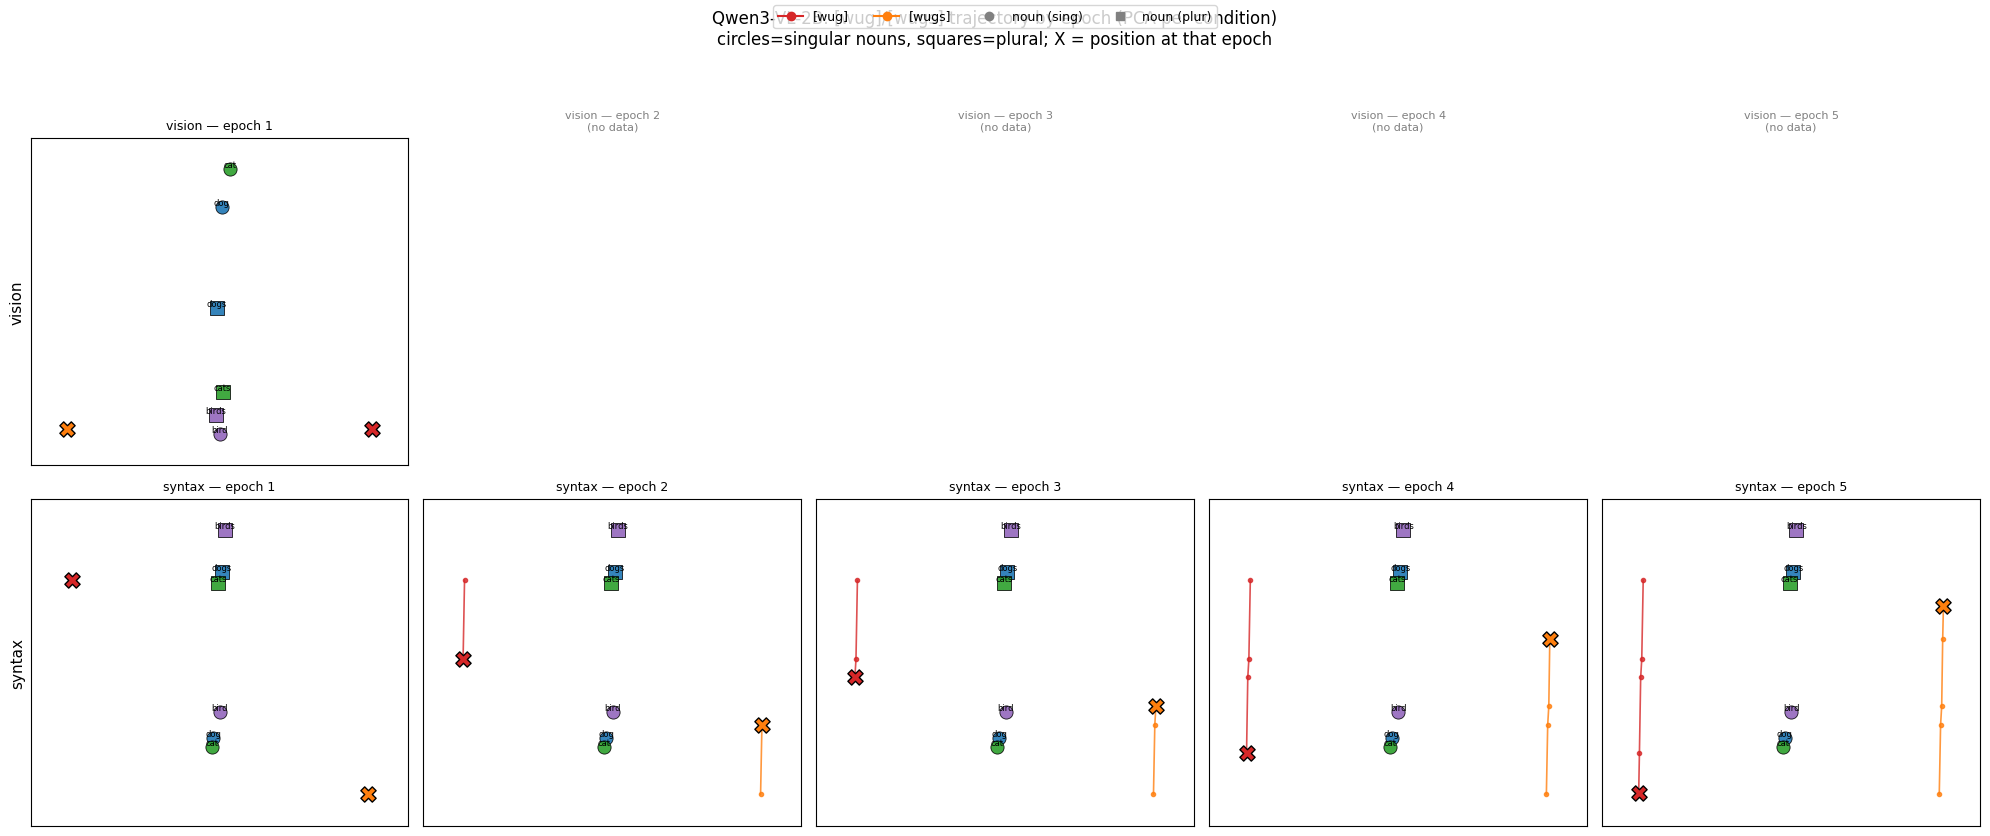

In [ ]:
import os, glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from minicons import scorer

# ---------------- load model once (reference nouns) ----------------
MODEL = "Qwen/Qwen3-VL-2B-Instruct"
CACHE_DIR = "/mnt/dv/wid/projects3/Rogers-muri-human-ai/zstuddiford"
lm = scorer.VLMScorer(MODEL, device="cuda", torch_dtype=torch.bfloat16, cache_dir=CACHE_DIR)

added_tokens = [" [wug]", " [wugs]"]
vocab = lm.tokenizer.tokenizer.get_vocab()
to_add = [t for t in added_tokens if t not in vocab]
if to_add:
    lm.tokenizer.tokenizer.add_tokens(to_add)
    old_len = lm.model.resize_token_embeddings().weight.shape[0]
    lm.model.resize_token_embeddings(old_len + len(to_add))

emb = lm.model.model.language_model.embed_tokens
tok = lm.tokenizer.tokenizer
ref_words = ["dog", "dogs", "cat", "cats", "bird", "birds"]
ref_ids = [tok(f" {w}", add_special_tokens=False).input_ids[0] for w in ref_words]
with torch.no_grad():
    ref_vecs = np.stack([emb.weight[i].float().cpu().numpy() for i in ref_ids])

# ---------------- locate the two runs ----------------
BASE = "../../results/final_embedding_results/Qwen3-VL-2B"
cond_glob = {
    "vision": os.path.join(BASE, "vision", "*", "epoch_embs"),
    "syntax": os.path.join(BASE, "syntax", "*", "epoch_embs"),
}

def load_traj(emb_glob):
    dirs = glob.glob(emb_glob)
    assert dirs, f"no epoch_embs under {emb_glob}"
    files = sorted(glob.glob(os.path.join(dirs[0], "epoch_*.pt")),
                   key=lambda p: int(os.path.basename(p).split("_")[1].split(".")[0]))
    # map epoch number -> (wug, wugs)
    by_epoch = {}
    wug, wugs, eps = [], [], []
    for p in files:
        rec = torch.load(p, map_location="cpu")
        w  = rec["wug_embedding"].float().numpy()
        ws = rec["wugs_embedding"].float().numpy()
        by_epoch[int(rec["epoch"])] = (w, ws)
        wug.append(w); wugs.append(ws); eps.append(int(rec["epoch"]))
    return {"by_epoch": by_epoch, "wug": np.stack(wug), "wugs": np.stack(wugs),
            "epochs": eps, "dir": dirs[0]}

trajs = {c: load_traj(g) for c, g in cond_glob.items()}
for c, t in trajs.items():
    print(f"{c}: epochs {t['epochs']} from {t['dir']}")

# ---------------- plot: 2 rows x 5 cols, col = epoch 1..5 ----------------
COLS = [1, 2, 3, 4, 5]
pair_colors = ["#1f77b4", "#2ca02c", "#9467bd"]

fig, axes = plt.subplots(2, len(COLS), figsize=(4 * len(COLS), 8), squeeze=False)

for row, cond in enumerate(["vision", "syntax"]):
    t = trajs[cond]
    pca = PCA(n_components=2, random_state=0).fit(np.vstack([t["wug"], t["wugs"]]))
    ref_xy  = pca.transform(ref_vecs)
    wug_xy  = pca.transform(t["wug"])
    wugs_xy = pca.transform(t["wugs"])

    # epoch number -> row index in the trajectory arrays
    ep_to_pos = {ep: i for i, ep in enumerate(t["epochs"])}

    # shared bounds across the row (traj + nouns)
    allxy = np.vstack([wug_xy, wugs_xy, ref_xy])
    xmin, ymin = allxy.min(0); xmax, ymax = allxy.max(0)
    mx = (xmax - xmin) * 0.12 or 1e-3; my = (ymax - ymin) * 0.12 or 1e-3

    for col, epoch in enumerate(COLS):
        ax = axes[row][col]

        # pad blank if this run never reached this epoch
        if epoch not in ep_to_pos:
            ax.axis("off")
            ax.set_title(f"{cond} — epoch {epoch}\n(no data)", fontsize=8, color="gray")
            continue

        pos = ep_to_pos[epoch]

        # noun anchors
        for k, (word, xy) in enumerate(zip(ref_words, ref_xy)):
            ax.scatter(*xy, marker=("s" if word.endswith("s") else "o"),
                       s=90, c=pair_colors[k // 2], edgecolors="black",
                       linewidths=0.6, zorder=4, alpha=0.9)
            ax.annotate(word, xy, fontsize=6, ha="center", va="bottom", zorder=5)

        # cumulative path up to this epoch + current position
        ax.plot(wug_xy[:pos+1, 0],  wug_xy[:pos+1, 1],  "-o",
                color="#d62728", ms=3, lw=1.2, alpha=0.8)
        ax.plot(wugs_xy[:pos+1, 0], wugs_xy[:pos+1, 1], "-o",
                color="#ff7f0e", ms=3, lw=1.2, alpha=0.8)
        ax.scatter(*wug_xy[pos],  marker="X", s=120, c="#d62728",
                   edgecolors="black", zorder=6)
        ax.scatter(*wugs_xy[pos], marker="X", s=120, c="#ff7f0e",
                   edgecolors="black", zorder=6)

        ax.set_xlim(xmin - mx, xmax + mx); ax.set_ylim(ymin - my, ymax + my)
        ax.set_title(f"{cond} — epoch {epoch}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

    axes[row][0].set_ylabel(cond, fontsize=11)

from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], color="#d62728", marker="o", label="[wug]"),
    Line2D([0],[0], color="#ff7f0e", marker="o", label="[wugs]"),
    Line2D([0],[0], color="gray", marker="o", ls="", label="noun (sing)"),
    Line2D([0],[0], color="gray", marker="s", ls="", label="noun (plur)"),
]
fig.legend(handles=handles, loc="upper center", ncol=4, fontsize=9)
fig.suptitle("Qwen3-VL-2B: [wug]/[wugs] trajectory by epoch (PCA per condition)\n"
             "circles=singular nouns, squares=plural; X = position at that epoch",
             y=1.04, fontsize=12)
plt.tight_layout()
plt.show()

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

vision: epochs [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] from ../../results/final_embedding_results/Qwen3-VL-4B/vision/_alternating_lr0p001_seed16672_ep50/epoch_embs
syntax: epochs [1, 2, 3] from ../../results/final_embedding_results/Qwen3-VL-4B/syntax/_alternating_lr0p001_seed19075_ep50/epoch_embs


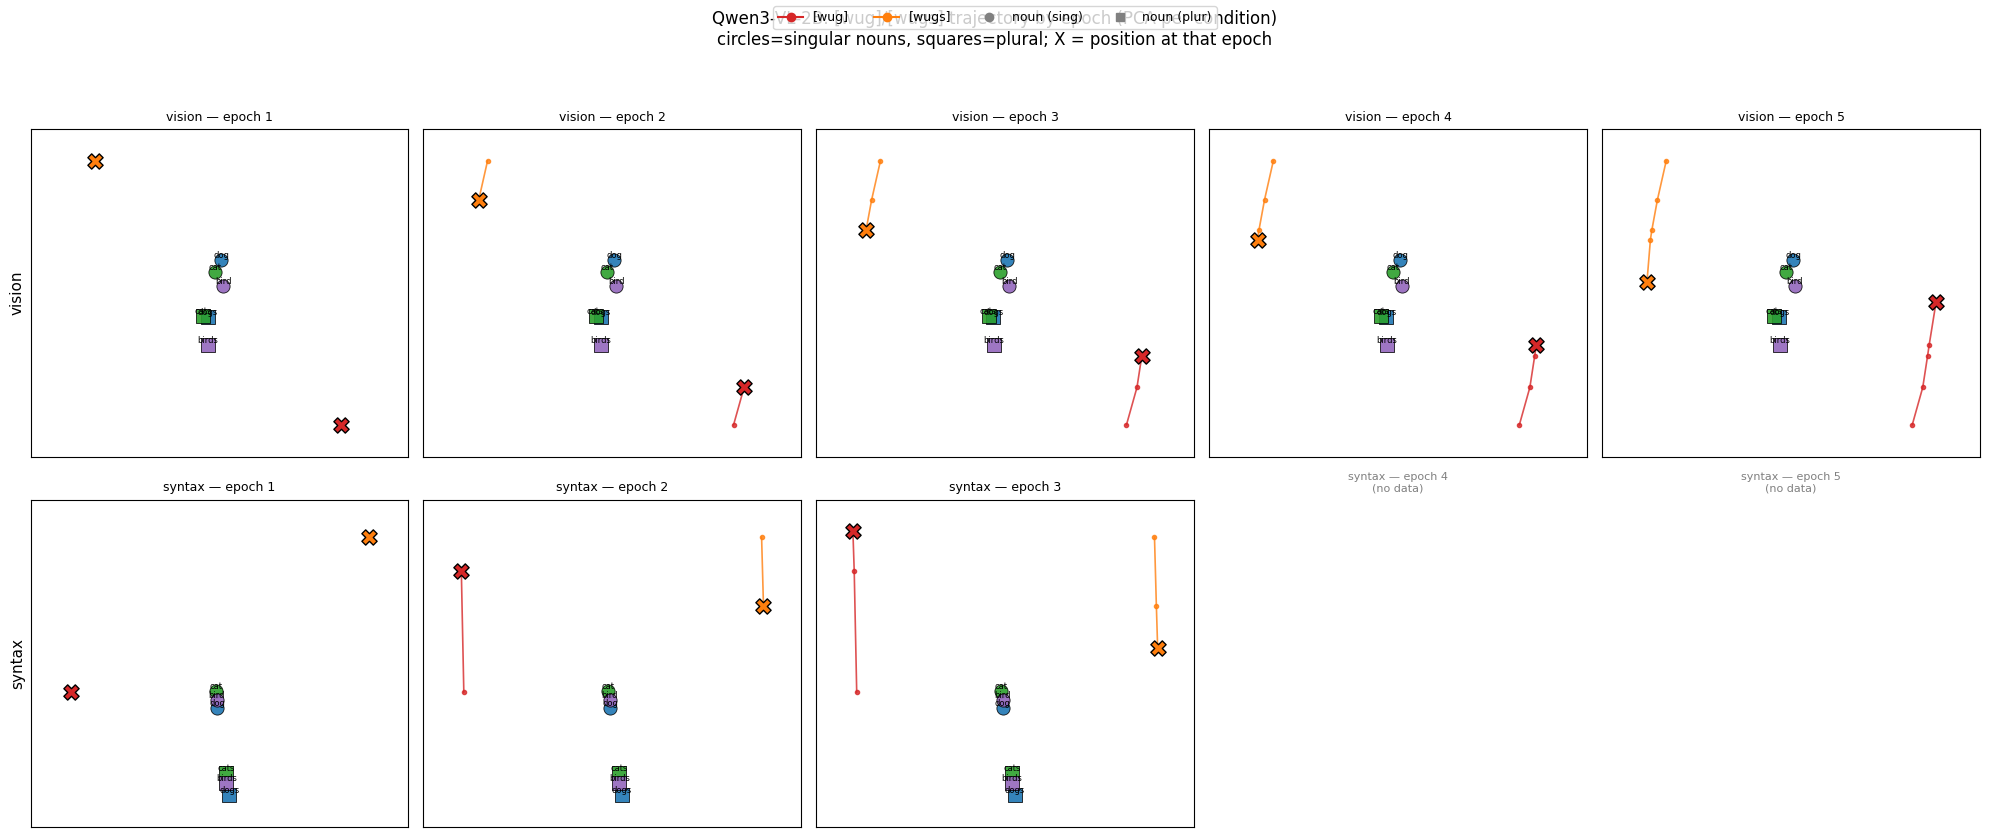

In [6]:
import os, glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from minicons import scorer

# ---------------- load model once (reference nouns) ----------------
MODEL = "Qwen/Qwen3-VL-4B-Instruct"
CACHE_DIR = "/mnt/dv/wid/projects3/Rogers-muri-human-ai/zstuddiford"
lm = scorer.VLMScorer(MODEL, device="cuda", torch_dtype=torch.bfloat16, cache_dir=CACHE_DIR)

added_tokens = [" [wug]", " [wugs]"]
vocab = lm.tokenizer.tokenizer.get_vocab()
to_add = [t for t in added_tokens if t not in vocab]
if to_add:
    lm.tokenizer.tokenizer.add_tokens(to_add)
    old_len = lm.model.resize_token_embeddings().weight.shape[0]
    lm.model.resize_token_embeddings(old_len + len(to_add))

emb = lm.model.model.language_model.embed_tokens
tok = lm.tokenizer.tokenizer
ref_words = ["dog", "dogs", "cat", "cats", "bird", "birds"]
ref_ids = [tok(f" {w}", add_special_tokens=False).input_ids[0] for w in ref_words]
with torch.no_grad():
    ref_vecs = np.stack([emb.weight[i].float().cpu().numpy() for i in ref_ids])

# ---------------- locate the two runs ----------------
BASE = "../../results/final_embedding_results/Qwen3-VL-4B"
cond_glob = {
    "vision": os.path.join(BASE, "vision", "*", "epoch_embs"),
    "syntax": os.path.join(BASE, "syntax", "*", "epoch_embs"),
}

def load_traj(emb_glob):
    dirs = glob.glob(emb_glob)
    assert dirs, f"no epoch_embs under {emb_glob}"
    files = sorted(glob.glob(os.path.join(dirs[0], "epoch_*.pt")),
                   key=lambda p: int(os.path.basename(p).split("_")[1].split(".")[0]))
    # map epoch number -> (wug, wugs)
    by_epoch = {}
    wug, wugs, eps = [], [], []
    for p in files:
        rec = torch.load(p, map_location="cpu")
        w  = rec["wug_embedding"].float().numpy()
        ws = rec["wugs_embedding"].float().numpy()
        by_epoch[int(rec["epoch"])] = (w, ws)
        wug.append(w); wugs.append(ws); eps.append(int(rec["epoch"]))
    return {"by_epoch": by_epoch, "wug": np.stack(wug), "wugs": np.stack(wugs),
            "epochs": eps, "dir": dirs[0]}

trajs = {c: load_traj(g) for c, g in cond_glob.items()}
for c, t in trajs.items():
    print(f"{c}: epochs {t['epochs']} from {t['dir']}")

# ---------------- plot: 2 rows x 5 cols, col = epoch 1..5 ----------------
COLS = [1, 2, 3, 4, 5]
pair_colors = ["#1f77b4", "#2ca02c", "#9467bd"]

fig, axes = plt.subplots(2, len(COLS), figsize=(4 * len(COLS), 8), squeeze=False)

for row, cond in enumerate(["vision", "syntax"]):
    t = trajs[cond]
    pca = PCA(n_components=2, random_state=0).fit(np.vstack([t["wug"], t["wugs"]]))
    ref_xy  = pca.transform(ref_vecs)
    wug_xy  = pca.transform(t["wug"])
    wugs_xy = pca.transform(t["wugs"])

    # epoch number -> row index in the trajectory arrays
    ep_to_pos = {ep: i for i, ep in enumerate(t["epochs"])}

    # shared bounds across the row (traj + nouns)
    allxy = np.vstack([wug_xy, wugs_xy, ref_xy])
    xmin, ymin = allxy.min(0); xmax, ymax = allxy.max(0)
    mx = (xmax - xmin) * 0.12 or 1e-3; my = (ymax - ymin) * 0.12 or 1e-3

    for col, epoch in enumerate(COLS):
        ax = axes[row][col]

        # pad blank if this run never reached this epoch
        if epoch not in ep_to_pos:
            ax.axis("off")
            ax.set_title(f"{cond} — epoch {epoch}\n(no data)", fontsize=8, color="gray")
            continue

        pos = ep_to_pos[epoch]

        # noun anchors
        for k, (word, xy) in enumerate(zip(ref_words, ref_xy)):
            ax.scatter(*xy, marker=("s" if word.endswith("s") else "o"),
                       s=90, c=pair_colors[k // 2], edgecolors="black",
                       linewidths=0.6, zorder=4, alpha=0.9)
            ax.annotate(word, xy, fontsize=6, ha="center", va="bottom", zorder=5)

        # cumulative path up to this epoch + current position
        ax.plot(wug_xy[:pos+1, 0],  wug_xy[:pos+1, 1],  "-o",
                color="#d62728", ms=3, lw=1.2, alpha=0.8)
        ax.plot(wugs_xy[:pos+1, 0], wugs_xy[:pos+1, 1], "-o",
                color="#ff7f0e", ms=3, lw=1.2, alpha=0.8)
        ax.scatter(*wug_xy[pos],  marker="X", s=120, c="#d62728",
                   edgecolors="black", zorder=6)
        ax.scatter(*wugs_xy[pos], marker="X", s=120, c="#ff7f0e",
                   edgecolors="black", zorder=6)

        ax.set_xlim(xmin - mx, xmax + mx); ax.set_ylim(ymin - my, ymax + my)
        ax.set_title(f"{cond} — epoch {epoch}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

    axes[row][0].set_ylabel(cond, fontsize=11)

from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], color="#d62728", marker="o", label="[wug]"),
    Line2D([0],[0], color="#ff7f0e", marker="o", label="[wugs]"),
    Line2D([0],[0], color="gray", marker="o", ls="", label="noun (sing)"),
    Line2D([0],[0], color="gray", marker="s", ls="", label="noun (plur)"),
]
fig.legend(handles=handles, loc="upper center", ncol=4, fontsize=9)
fig.suptitle("Qwen3-VL-2B: [wug]/[wugs] trajectory by epoch (PCA per condition)\n"
             "circles=singular nouns, squares=plural; X = position at that epoch",
             y=1.04, fontsize=12)
plt.tight_layout()
plt.show()